<a href="https://colab.research.google.com/github/fajriantomanungki/lomba_kti/blob/main/Data/collect_NTL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install geemap geopandas -q

In [4]:
import ee
import geemap
import geopandas as gpd
import pandas as pd
import os

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
project_path = "/content/drive/MyDrive/Karya Ilmiah/AEDS_Sulampua"

data_path = f"{project_path}/data"
output_path = f"{project_path}/output"

os.makedirs(data_path, exist_ok=True)
os.makedirs(output_path, exist_ok=True)

In [10]:
ee.Authenticate()
ee.Initialize(project="aedcbankindonesia")

In [12]:
kabkot_path = f"{data_path}/batas_kabkot_sulampua.geojson"

kabkot_gdf = gpd.read_file(kabkot_path)
kabkot_gdf.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
0,IDN.6.1_1,IDN,Indonesia,IDN.6_1,Gorontalo,NA,Boalemo,NA,NA,Kabupaten,Regency,7501,ID.GO.BO,"MULTIPOLYGON (((122.6306 0.4871, 122.6248 0.48..."
1,IDN.6.2_1,IDN,Indonesia,IDN.6_1,Gorontalo,NA,BoneBolango,NA,NA,Kabupaten,Regency,7504,ID.GO.BB,"MULTIPOLYGON (((123.4632 0.3317, 123.4637 0.33..."
2,IDN.6.3_1,IDN,Indonesia,IDN.6_1,Gorontalo,NA,DanauLimboto,NA,NA,Kabupaten,Regency,7502,ID.GO.GO,"MULTIPOLYGON (((122.9845 0.5558, 122.982 0.558..."
3,IDN.6.5_1,IDN,Indonesia,IDN.6_1,Gorontalo,NA,Gorontalo,NA,NA,Kabupaten,Regency,7502,ID.GO.GO,"MULTIPOLYGON (((122.9869 0.5547, 122.9966 0.55..."
4,IDN.6.4_1,IDN,Indonesia,IDN.6_1,Gorontalo,NA,GorontaloUtara,NA,NA,Kabupaten,Regency,7505,ID.GO.GU,"MULTIPOLYGON (((122.8156 0.8488, 122.8174 0.84..."


In [13]:
kabkot_gdf.columns

Index(['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2',
       'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2',
       'geometry'],
      dtype='object')

In [14]:
kabkot_gdf = kabkot_gdf.to_crs(epsg=4326)

<Axes: >

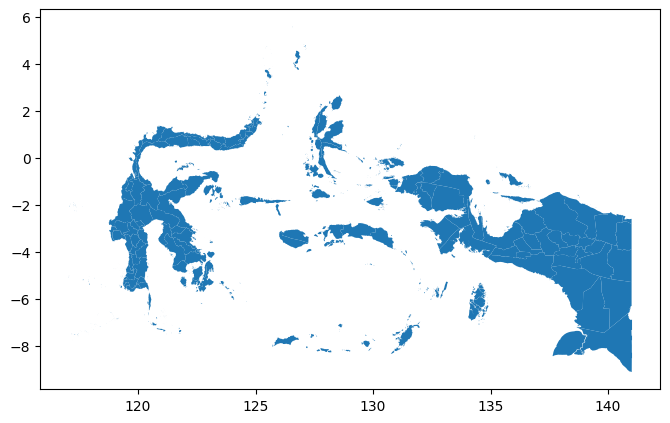

In [15]:
kabkot_gdf.plot(figsize=(8, 8))

In [16]:
sulampua_provinces = [
    "SulawesiUtara",
    "Gorontalo",
    "SulawesiTengah",
    "SulawesiBarat",
    "SulawesiSelatan",
    "SulawesiTenggara",
    "Maluku",
    "MalukuUtara",
    "Papua",
    "PapuaBarat",
    "PapuaSelatan",
    "PapuaTengah",
    "PapuaPegunungan",
    "PapuaBaratDaya"
]

kabkot_sulampua = kabkot_gdf[
    kabkot_gdf["NAME_1"].isin(sulampua_provinces)
].copy()

In [17]:
kabkot_sulampua_path = f"{output_path}/kabkot_sulampua.geojson"

kabkot_sulampua.to_file(kabkot_sulampua_path, driver="GeoJSON")

In [18]:
kabkot_ee = geemap.geopandas_to_ee(kabkot_sulampua)

In [19]:
start_date = "2025-01-01"
end_date = "2025-12-31"

viirs = (
    ee.ImageCollection("NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG")
    .filterDate(start_date, end_date)
    .select(["avg_rad", "cf_cvg"])
)

In [20]:
viirs.size().getInfo()

12

In [21]:
def clean_viirs(img):
    rad = img.select("avg_rad")
    coverage = img.select("cf_cvg")

    cleaned = (
        rad
        .updateMask(rad.gte(0))
        .updateMask(coverage.gte(3))
    )

    return cleaned.copyProperties(img, img.propertyNames())

ntl_clean = viirs.map(clean_viirs)

In [22]:
ntl_annual = ntl_clean.mean().rename("ntl_mean_2025")

In [24]:
reducer = (
    ee.Reducer.mean()
    .combine(reducer2=ee.Reducer.sum(), sharedInputs=True)
    .combine(reducer2=ee.Reducer.max(), sharedInputs=True)
    .combine(reducer2=ee.Reducer.median(), sharedInputs=True)
)

ntl_zonal = ntl_annual.reduceRegions(
    collection=kabkot_ee,
    reducer=reducer,
    scale=500
)

In [25]:
csv_path = f"{output_path}/ntl_sulampua_2025.csv"

geemap.ee_export_vector(
    ntl_zonal,
    filename=csv_path
)

Generating URL ...
Please wait ...
Data downloaded to /content/drive/MyDrive/Karya Ilmiah/AEDS_Sulampua/output/ntl_sulampua_2025.csv


In [26]:
ntl_df = pd.read_csv(csv_path)
ntl_df.head()

,mean,sum,max,median,system:index,ENGTYPE_2,NL_NAME_2,HASC_2,NL_NAME_1,CC_2,NAME_2,NAME_1,TYPE_2,COUNTRY,GID_0,GID_1,GID_2,VARNAME_2
0,0.365091,2711.358556,8.7750,0.275982,0,Regency,NaN,ID.GO.BO,NaN,7501,Boalemo,Gorontalo,Kabupaten,Indonesia,IDN,IDN.6_1,IDN.6.1_1,NaN
1,0.466742,3579.925729,16.0875,0.275200,1,Regency,NaN,ID.GO.BB,NaN,7504,BoneBolango,Gorontalo,Kabupaten,Indonesia,IDN,IDN.6_1,IDN.6.2_1,NaN
2,1.004927,109.497682,4.8700,0.736546,2,Regency,NaN,ID.GO.GO,NaN,7502,DanauLimboto,Gorontalo,Kabupaten,Indonesia,IDN,IDN.6_1,IDN.6.3_1,NaN
3,0.601666,5164.962592,15.5425,0.339403,3,Regency,NaN,ID.GO.GO,NaN,7502,Gorontalo,Gorontalo,Kabupaten,Indonesia,IDN,IDN.6_1,IDN.6.5_1,NaN
4,0.361140,2477.825210,21.4200,0.290031,4,Regency,NaN,ID.GO.GU,NaN,7505,GorontaloUtara,Gorontalo,Kabupaten,Indonesia,IDN,IDN.6_1,IDN.6.4_1,NaN


In [27]:
ntl_df = ntl_df.rename(columns={
    "mean": "ntl_mean",
    "sum": "ntl_sum",
    "max": "ntl_max",
    "median": "ntl_median"
})

In [28]:
def minmax(series):
    return 100 * (series - series.min()) / (series.max() - series.min())

ntl_df["ntl_index_0_100"] = minmax(ntl_df["ntl_mean"])

In [33]:
ntl_df["ntl_sum_index_0_100"] = minmax(ntl_df["ntl_sum"])

ntl_df["ntl_dimension_index"] = (
    0.6 * ntl_df["ntl_index_0_100"] +
    0.4 * ntl_df["ntl_sum_index_0_100"]
)

In [34]:
final_csv_path = f"{output_path}/ntl_sulampua_2025_final.csv"

ntl_df.to_csv(final_csv_path, index=False)

final_csv_path

'/content/drive/MyDrive/Karya Ilmiah/AEDS_Sulampua/output/ntl_sulampua_2025_final.csv'

In [35]:
ntl_geo = kabkot_sulampua.merge(
    ntl_df,
    on="NAME_2",
    how="left"
)

In [36]:
final_geojson_path = f"{output_path}/ntl_sulampua_2025_final.geojson"

ntl_geo.to_file(final_geojson_path, driver="GeoJSON")

final_geojson_path

'/content/drive/MyDrive/Karya Ilmiah/AEDS_Sulampua/output/ntl_sulampua_2025_final.geojson'